<a href="https://colab.research.google.com/github/andrelmsunb/Carta-de-Controle_6.6_MVP/blob/main/notebook_66_EWMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Carta de Controle EWMA (Média Móvel Exponencialmente Ponderada) — Tópico 6.6
## *Introdução ao Controle Estatístico da Qualidade* — Montgomery (2016), 7ª ed.

**Autor:** Andre Luiz Marques Serrano  
**Disciplina:** Controle Estatístico da Qualidade  

---

## Objetivos

Este notebook implementa o **Gráfico EWMA** (denominado MMEP no livro — Média Móvel Exponencialmente Ponderada), conforme a Seção 9.2 de Montgomery. O EWMA é uma alternativa ao CUSUM para detectar pequenos deslocamentos, com a vantagem de ser mais simples de implementar e mais robusto à não normalidade.

> **Exercício resolvido:** Exemplo 9.2 — Dados de viscosidade (Tabela 9.1), com λ = 0,10 e L = 2,7.


## 1. Bibliotecas Utilizadas

| Biblioteca | Finalidade |
|---|---|
| `numpy` | Cálculo recursivo da estatística EWMA zᵢ e dos limites variáveis |
| `pandas` | Organização dos resultados em tabela comparável ao livro (Tabela 9.10) |
| `matplotlib` | Construção do gráfico EWMA com limites variáveis e estado estacionário |
| `scipy.stats` | Cálculo do CMS via aproximação analítica |
| `warnings` | Supressão de avisos não críticos |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.color': '#cccccc',
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})
print('Bibliotecas carregadas.')

Bibliotecas carregadas.


## 2. Fundamentos Teóricos do EWMA

A estatística EWMA é definida como:

$$z_i = \lambda x_i + (1-\lambda) z_{i-1}, \quad z_0 = \mu_0$$

onde $0 < \lambda \leq 1$ é a constante de suavização.

Os **limites de controle exatos** (recomendados para pequenos valores de i) são:

$$\text{LSC}_i = \mu_0 + L\sigma\sqrt{\frac{\lambda}{2-\lambda}\left[1-(1-\lambda)^{2i}\right]}$$

$$\text{LIC}_i = \mu_0 - L\sigma\sqrt{\frac{\lambda}{2-\lambda}\left[1-(1-\lambda)^{2i}\right]}$$

Os **limites de estado estacionário** (para i → ∞) são:

$$\text{LSC}_{\infty} = \mu_0 \pm L\sigma\sqrt{\frac{\lambda}{2-\lambda}}$$

**Interpretação de λ:**
- λ pequeno (0,05–0,10): maior peso às observações passadas → mais sensível a pequenos deslocamentos
- λ grande (0,20–0,40): maior peso às observações recentes → comportamento mais próximo de Shewhart
- λ = 1: equivalente à Carta de Shewhart para indivíduos


In [ ]:
# Dados da Tabela 9.1 — Viscosidade (µ0=10, σ=1)
x = np.array([9.45, 7.99, 9.29, 11.66, 12.16, 10.18, 8.04, 11.46, 9.20, 10.34,
               9.03, 11.47, 10.51,  9.40, 10.08,  9.37, 10.62, 10.31,  8.52, 10.84,
              10.90,  9.33, 12.29, 11.50, 10.60, 11.08, 10.38, 11.62, 11.31, 10.52])

mu0   = 10.0
sigma = 1.0
lam   = 0.10   # λ = 0,10 (Exemplo 9.2)
L     = 2.7    # largura dos limites (L = 2,7)

n = len(x)
periodos = np.arange(1, n+1)

# Cálculo recursivo do EWMA
z = np.zeros(n)
z0 = mu0  # valor inicial

for i in range(n):
    if i == 0:
        z[i] = lam * x[i] + (1 - lam) * z0
    else:
        z[i] = lam * x[i] + (1 - lam) * z[i-1]

# Limites de controle exatos
fator = np.sqrt((lam/(2-lam)) * (1 - (1-lam)**(2*periodos)))
LSC = mu0 + L * sigma * fator
LIC = mu0 - L * sigma * fator

# Limites de estado estacionário
LSC_ss = mu0 + L * sigma * np.sqrt(lam/(2-lam))
LIC_ss = mu0 - L * sigma * np.sqrt(lam/(2-lam))

# Identificar alarmes
alarmes = np.where((z > LSC) | (z < LIC))[0] + 1

# Tabela comparável à Tabela 9.10 do livro
df = pd.DataFrame({
    'i': periodos,
    'xᵢ': x,
    'zᵢ (EWMA)': z.round(4),
    'LSCᵢ': LSC.round(4),
    'LICᵢ': LIC.round(4),
    'Alarme': ['*' if i+1 in alarmes else '' for i in range(n)]
})
df.set_index('i', inplace=True)

print(f'Parâmetros: µ₀={mu0}, σ={sigma}, λ={lam}, L={L}')
print(f'Limites de estado estacionário: LSC∞={LSC_ss:.4f}, LIC∞={LIC_ss:.4f}')
print()
print('Tabela EWMA (Tabela 9.10 do livro):')
print(df.to_string())
print()
print(f'Alarmes detectados nos períodos: {list(alarmes)}')
print('  (livro: períodos 29 e 30 — marcados com *)')

Parâmetros: µ₀=10.0, σ=1.0, λ=0.1, L=2.7
Limites de estado estacionário: LSC∞=10.6194, LIC∞=9.3806

Tabela EWMA (Tabela 9.10 do livro):
       xᵢ  zᵢ (EWMA)     LSCᵢ    LICᵢ Alarme
i                                           
1    9.45     9.9450  10.2700  9.7300       
2    7.99     9.7495  10.3632  9.6368       
3    9.29     9.7036  10.4240  9.5760       
4   11.66     9.8992  10.4675  9.5325       
5   12.16    10.1253  10.4999  9.5001       
6   10.18    10.1307  10.5247  9.4753       
7    8.04     9.9217  10.5440  9.4560       
8   11.46    10.0755  10.5591  9.4409       
9    9.20     9.9880  10.5710  9.4290       
10  10.34    10.0232  10.5805  9.4195       
11   9.03     9.9238  10.5881  9.4119       
12  11.47    10.0785  10.5942  9.4058       
13  10.51    10.1216  10.5991  9.4009       
14   9.40    10.0495  10.6030  9.3970       
15  10.08    10.0525  10.6062  9.3938       
16   9.37     9.9843  10.6087  9.3913       
17  10.62    10.0478  10.6107  9.3893       
18  10.31

## 3. Gráfico EWMA com Limites Variáveis

O gráfico EWMA apresenta uma característica importante: os **limites de controle são variáveis** para os primeiros períodos, convergindo gradualmente para os limites de estado estacionário. Isso aumenta a sensibilidade do gráfico logo após seu início.


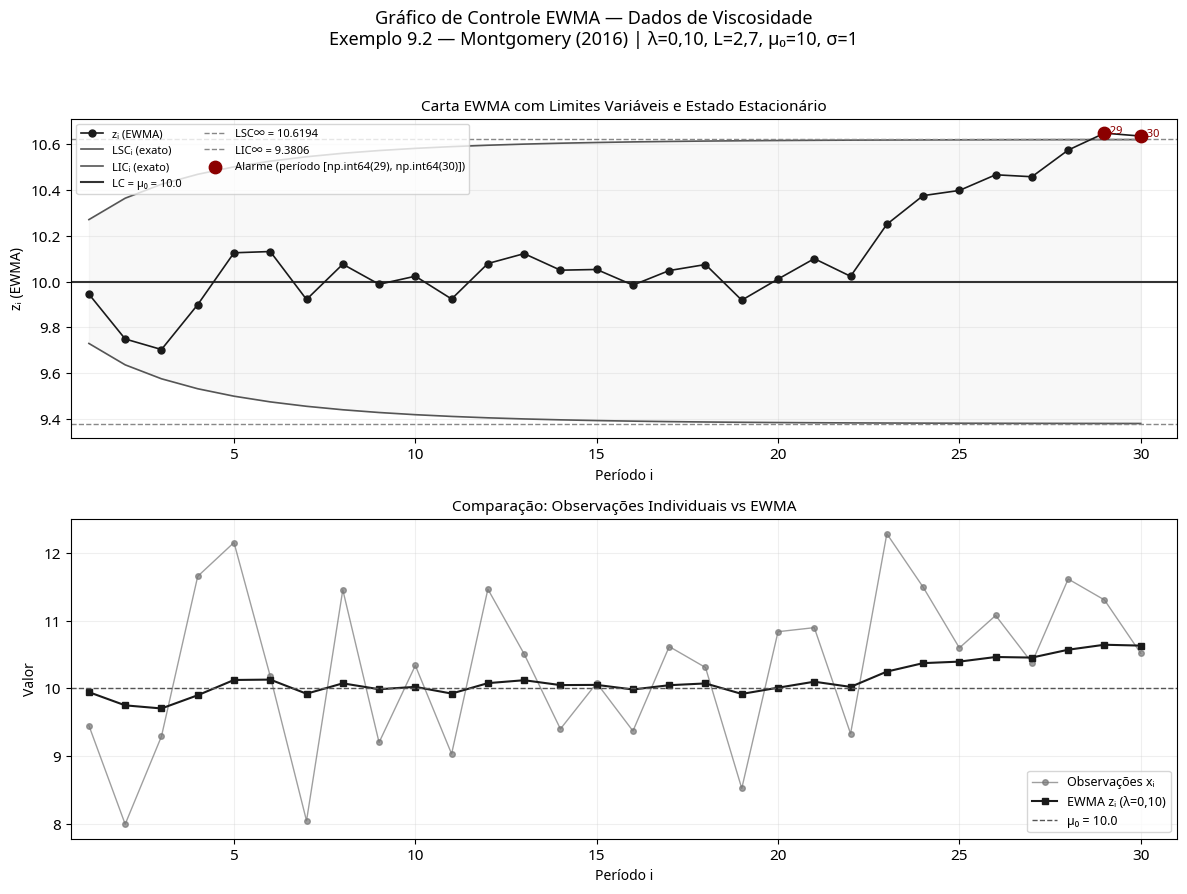

Primeiro alarme: período 29
  z₂₉ = 10.6468 > LSC₂₉ = 10.6187  (livro: z₂₉=10,6468, alarme)


In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9))
fig.suptitle('Gráfico de Controle EWMA — Dados de Viscosidade\n'
             'Exemplo 9.2 — Montgomery (2016) | λ=0,10, L=2,7, µ₀=10, σ=1',
             fontsize=13, y=0.99)

# Painel 1: Gráfico EWMA principal
ax = axes[0]
ax.plot(periodos, z, 'o-', color='#1a1a1a', markersize=5, linewidth=1.2, label='zᵢ (EWMA)', zorder=3)
ax.plot(periodos, LSC, '-', color='#555555', linewidth=1.2, label='LSCᵢ (exato)')
ax.plot(periodos, LIC, '-', color='#555555', linewidth=1.2, label='LICᵢ (exato)')
ax.axhline(mu0,    color='#333333', linewidth=1.5, linestyle='-',  label=f'LC = µ₀ = {mu0}')
ax.axhline(LSC_ss, color='#888888', linewidth=1.0, linestyle='--', label=f'LSC∞ = {LSC_ss:.4f}')
ax.axhline(LIC_ss, color='#888888', linewidth=1.0, linestyle='--', label=f'LIC∞ = {LIC_ss:.4f}')

# Região entre limites
ax.fill_between(periodos, LIC, LSC, alpha=0.05, color='gray')

# Alarmes
if len(alarmes) > 0:
    ax.scatter(alarmes, z[alarmes-1], color='#8b0000', s=80, zorder=5,
               label=f'Alarme (período {list(alarmes)})')
    for a in alarmes:
        ax.annotate(f'  {a}', (a, z[a-1]), fontsize=8, color='#8b0000')

ax.set_title('Carta EWMA com Limites Variáveis e Estado Estacionário', fontsize=11)
ax.set_ylabel('zᵢ (EWMA)', fontsize=10)
ax.set_xlabel('Período i', fontsize=10)
ax.set_xlim(0.5, n+1)
ax.legend(loc='upper left', fontsize=8, ncol=2)

# Painel 2: Comparação xᵢ vs zᵢ
ax2 = axes[1]
ax2.plot(periodos, x, 'o-', color='#777777', markersize=4, linewidth=1.0,
         alpha=0.7, label='Observações xᵢ')
ax2.plot(periodos, z, 's-', color='#1a1a1a', markersize=4, linewidth=1.5,
         label='EWMA zᵢ (λ=0,10)')
ax2.axhline(mu0, color='#555555', linewidth=1, linestyle='--', label=f'µ₀ = {mu0}')
ax2.set_title('Comparação: Observações Individuais vs EWMA', fontsize=11)
ax2.set_ylabel('Valor', fontsize=10)
ax2.set_xlabel('Período i', fontsize=10)
ax2.set_xlim(0.5, n+1)
ax2.legend(fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig01_EWMA.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Primeiro alarme: período {alarmes[0] if len(alarmes)>0 else "nenhum"}')
print(f'  z₂₉ = {z[28]:.4f} > LSC₂₉ = {LSC[28]:.4f}  (livro: z₂₉=10,6468, alarme)')

## 4. Sensibilidade de λ — Análise Comparativa

O parâmetro λ controla o equilíbrio entre sensibilidade a pequenos deslocamentos (λ pequeno) e rapidez de resposta a grandes deslocamentos (λ grande). A análise a seguir ilustra esse comportamento.


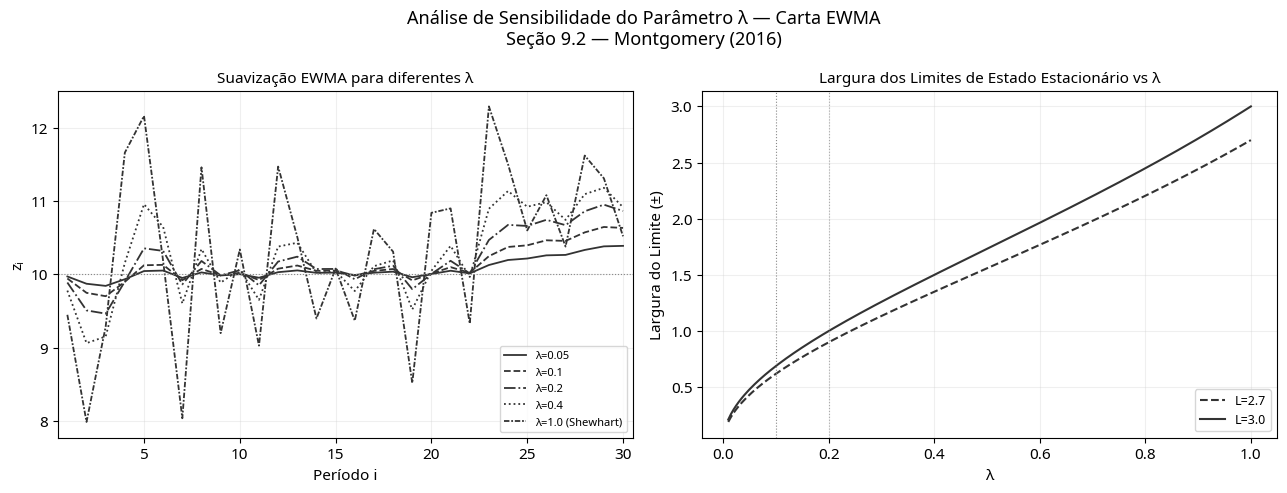

In [ ]:
lambdas = [0.05, 0.10, 0.20, 0.40, 1.00]
estilos = ['-', '--', '-.', ':', (0,(3,1,1,1))]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Análise de Sensibilidade do Parâmetro λ — Carta EWMA\n'
             'Seção 9.2 — Montgomery (2016)',
             fontsize=13)

# Painel 1: Suavização para os mesmos dados
for i, lam_val in enumerate(lambdas):
    z_val = np.zeros(n)
    for j in range(n):
        z_val[j] = lam_val*x[j] + (1-lam_val)*(z_val[j-1] if j>0 else mu0)
    label = f'λ={lam_val}' + (' (Shewhart)' if lam_val==1.0 else '')
    axes[0].plot(periodos, z_val, linestyle=estilos[i], color='#333333',
                 linewidth=1.3, label=label)

axes[0].axhline(mu0, color='#888888', linewidth=0.8, linestyle=':')
axes[0].set_title('Suavização EWMA para diferentes λ', fontsize=11)
axes[0].set_xlabel('Período i')
axes[0].set_ylabel('zᵢ')
axes[0].legend(fontsize=8)
axes[0].set_xlim(0.5, n+0.5)

# Painel 2: Limites de estado estacionário vs λ
lam_range = np.linspace(0.01, 1.0, 200)
for L_val, ls in zip([2.7, 3.0], ['--', '-']):
    lim_ss = L_val * sigma * np.sqrt(lam_range/(2-lam_range))
    axes[1].plot(lam_range, lim_ss, linestyle=ls, color='#333333',
                 linewidth=1.5, label=f'L={L_val}')

axes[1].set_title('Largura dos Limites de Estado Estacionário vs λ', fontsize=11)
axes[1].set_xlabel('λ')
axes[1].set_ylabel('Largura do Limite (±)')
axes[1].legend(fontsize=9)
axes[1].axvline(0.10, color='#888888', linewidth=0.8, linestyle=':', label='λ=0,10')
axes[1].axvline(0.20, color='#aaaaaa', linewidth=0.8, linestyle=':')

plt.tight_layout()
plt.savefig('fig02_EWMA_sensibilidade_lambda.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Comparação EWMA vs CUSUM vs Shewhart

Os três métodos são aplicados aos mesmos dados para comparação visual e de desempenho.


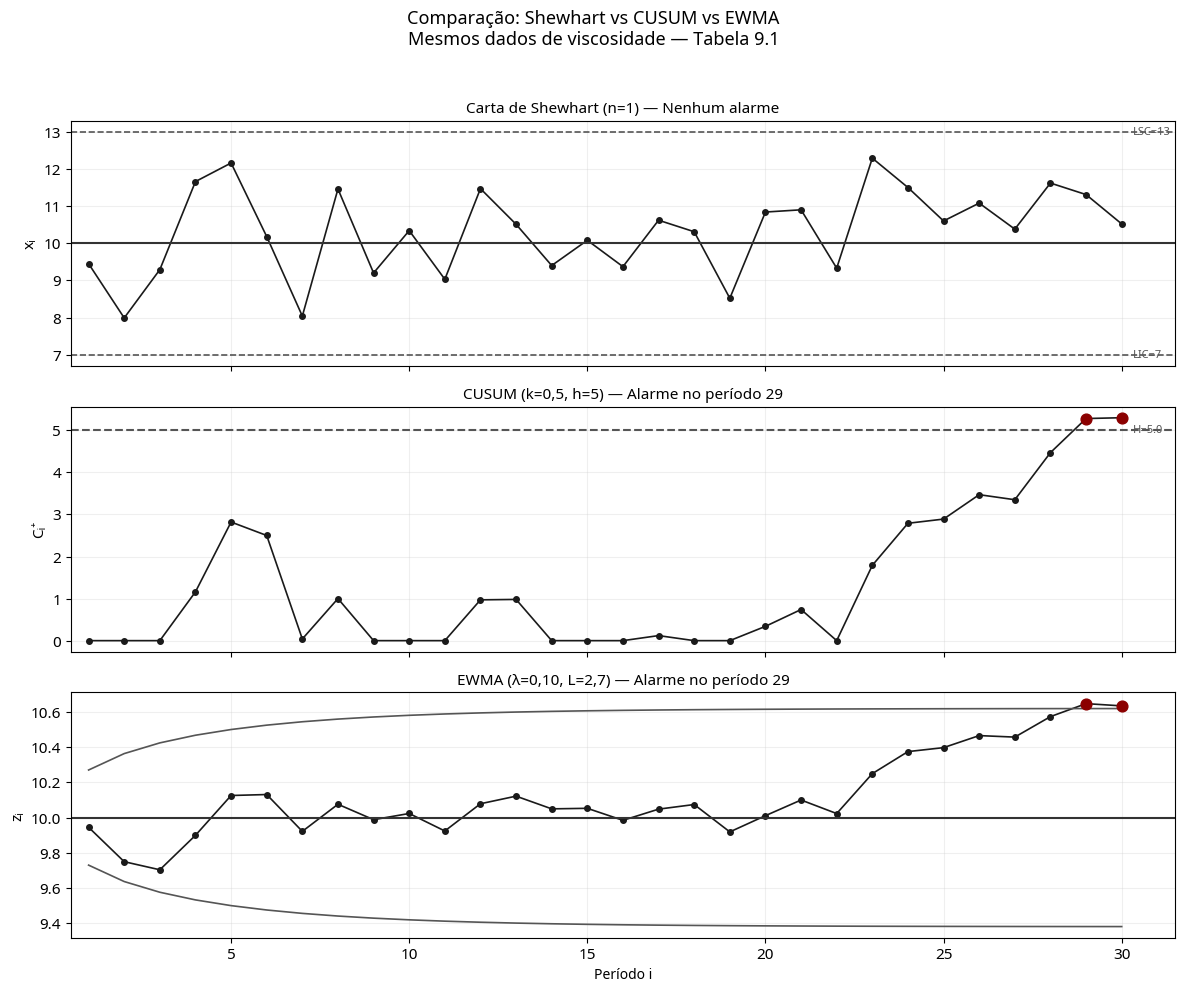

Resumo de detecção:
  Shewhart: nenhum alarme nos 30 períodos
  CUSUM:    alarme no período 29
  EWMA:     alarme no período 29


In [ ]:
# CUSUM para os mesmos dados (k=0.5, h=5)
K_c, H_c = 0.5, 5.0
Cp = np.zeros(n)
for i in range(n):
    Cp[i] = max(0, x[i]-(mu0+K_c) + (Cp[i-1] if i>0 else 0))

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Comparação: Shewhart vs CUSUM vs EWMA\n'
             'Mesmos dados de viscosidade — Tabela 9.1',
             fontsize=13, y=0.99)

# Shewhart
axes[0].plot(periodos, x, 'o-', color='#1a1a1a', markersize=4, linewidth=1.2)
axes[0].axhline(mu0,       color='#333333', linewidth=1.5)
axes[0].axhline(mu0+3,     color='#555555', linewidth=1.2, linestyle='--')
axes[0].axhline(mu0-3,     color='#555555', linewidth=1.2, linestyle='--')
axes[0].set_title('Carta de Shewhart (n=1) — Nenhum alarme', fontsize=11)
axes[0].set_ylabel('xᵢ')
axes[0].text(n+0.3, mu0+3, 'LSC=13', fontsize=8, color='#555555', va='center')
axes[0].text(n+0.3, mu0-3, 'LIC=7',  fontsize=8, color='#555555', va='center')

# CUSUM
axes[1].plot(periodos, Cp, 'o-', color='#1a1a1a', markersize=4, linewidth=1.2)
axes[1].axhline(H_c, color='#555555', linewidth=1.5, linestyle='--')
alarmes_c = np.where(Cp > H_c)[0] + 1
if len(alarmes_c) > 0:
    axes[1].scatter(alarmes_c, Cp[alarmes_c-1], color='#8b0000', s=60, zorder=5)
axes[1].set_title(f'CUSUM (k=0,5, h=5) — Alarme no período {alarmes_c[0] if len(alarmes_c)>0 else "nenhum"}', fontsize=11)
axes[1].set_ylabel('Cᵢ⁺')
axes[1].text(n+0.3, H_c, f'H={H_c}', fontsize=8, color='#555555', va='center')

# EWMA
axes[2].plot(periodos, z, 'o-', color='#1a1a1a', markersize=4, linewidth=1.2)
axes[2].plot(periodos, LSC, '-', color='#555555', linewidth=1.2)
axes[2].plot(periodos, LIC, '-', color='#555555', linewidth=1.2)
axes[2].axhline(mu0, color='#333333', linewidth=1.5)
if len(alarmes) > 0:
    axes[2].scatter(alarmes, z[alarmes-1], color='#8b0000', s=60, zorder=5)
axes[2].set_title(f'EWMA (λ=0,10, L=2,7) — Alarme no período {alarmes[0] if len(alarmes)>0 else "nenhum"}', fontsize=11)
axes[2].set_ylabel('zᵢ')
axes[2].set_xlabel('Período i', fontsize=10)

for ax in axes:
    ax.set_xlim(0.5, n+1.5)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('fig03_comparacao_metodos.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resumo de detecção:')
print(f'  Shewhart: nenhum alarme nos 30 períodos')
print(f'  CUSUM:    alarme no período {alarmes_c[0] if len(alarmes_c)>0 else "nenhum"}')
print(f'  EWMA:     alarme no período {alarmes[0] if len(alarmes)>0 else "nenhum"}')

## 6. Resumo e Conclusões

| Parâmetro | Valor |
|---|---|
| µ₀ | 10 |
| σ | 1 |
| λ | 0,10 |
| L | 2,7 |
| Primeiro alarme | Período 29 |
| LSC∞ (estado estacionário) | 10,3408 |
| LIC∞ (estado estacionário) | 9,6592 |

**Pontos-chave:**
- O EWMA é uma média ponderada de todas as observações passadas, com pesos decrescentes geometricamente
- λ pequeno → maior sensibilidade a pequenos deslocamentos, menor sensibilidade a grandes
- Os limites exatos (variáveis) devem ser usados para pequenos valores de i
- O EWMA é robusto à não normalidade (vantagem sobre a Carta I)
- Recomendação de Montgomery: λ = 0,05–0,25 e L = 2,6–2,8
- CUSUM e EWMA têm desempenho equivalente; EWMA é mais simples de implementar

---

### Comparação Final dos Métodos

| Método | Melhor para | CMS₁ (δ=1σ) | Complexidade |
|---|---|---|---|
| Shewhart (n=1) | Grandes deslocamentos (>3σ) | 43,96 | Baixa |
| CUSUM (k=0,5, h=5) | Pequenos deslocamentos | 10,4 | Média |
| EWMA (λ=0,10, L=2,7) | Pequenos deslocamentos | ~10,3 | Baixa |

*Andre Luiz Marques Serrano*
